In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

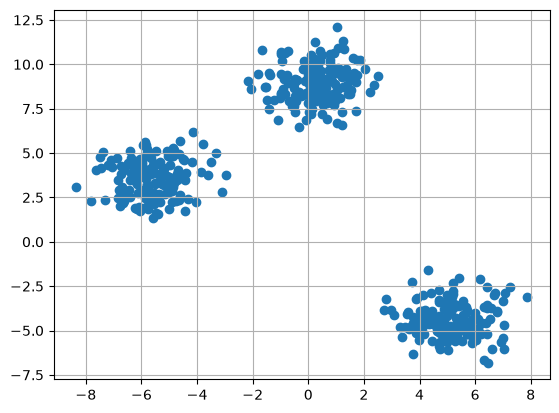

In [4]:
x,y = make_blobs(n_samples=500,n_features=2,centers=3,random_state=23)

plt.grid(True)
plt.scatter(x[:,0],x[:,1])
plt.show()


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x=scaler.fit_transform(x)

In [6]:
k=3
clusters={}
np.random.seed(23)

for idx in range(k):
    center = 2*(2*np.random.random((x.shape[1],))-1)
    points=[]
    cluster={
        'center':center,
        "points":[]
    }

    clusters[idx]=cluster
clusters

{0: {'center': array([0.06919154, 1.78785042]), 'points': []},
 1: {'center': array([ 1.06183904, -0.87041662]), 'points': []},
 2: {'center': array([-1.11581855,  0.74488834]), 'points': []}}

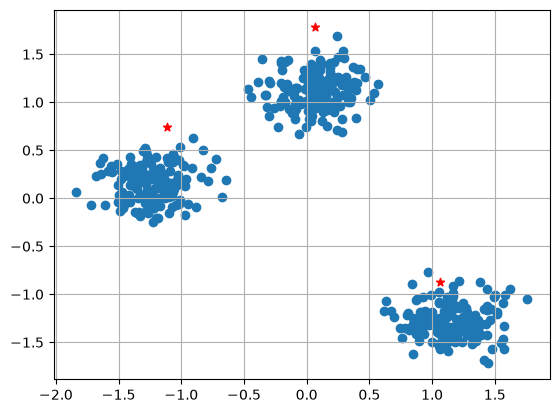

In [7]:
plt.scatter(x[:,0],x[:,1])
plt.grid(True)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker='*',c='red')
plt.show()

In [8]:
def distance(p1,p2):
    return np.sqrt(np.sqrt(np.sum((p1-p2) **2)))

In [9]:
def assign_clusters(X, clusters):
    for idx in range(X.shape[0]):
        dist = []
        
        curr_x = X[idx]
        
        for i in range(k):
            dis = distance(curr_x,clusters[i]['center'])
            dist.append(dis)
        curr_cluster = np.argmin(dist)
        clusters[curr_cluster]['points'].append(curr_x)
    return clusters

def update_clusters(X, clusters):
    for i in range(k):
        points = np.array(clusters[i]['points'])
        if points.shape[0] > 0:
            new_center = points.mean(axis =0)
            clusters[i]['center'] = new_center
            
            clusters[i]['points'] = []
    return clusters

In [10]:
def pred_cluster(X, clusters):
    pred = []
    for i in range(X.shape[0]):
        dist = []
        for j in range(k):
            dist.append(distance(X[i],clusters[j]['center']))
        pred.append(np.argmin(dist))
    return pred

In [13]:
# Repeat until convergence or maximum iterations
max_iters = 100

for _ in range(max_iters):
    old_centers = [clusters[i]['center'].copy() for i in range(k)]

    clusters = assign_clusters(x, clusters)
    clusters = update_clusters(x, clusters)

    new_centers = [clusters[i]['center'] for i in range(k)]

    if np.allclose(old_centers, new_centers):
        break

pred = pred_cluster(x, clusters)

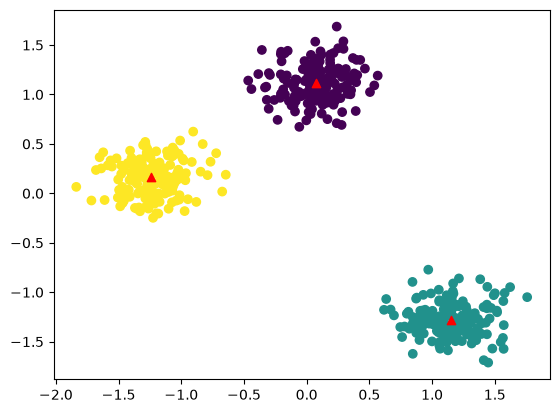

In [15]:
plt.scatter(x[:,0],x[:,1],c = pred)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '^',c = 'red')
plt.show()